# The Metal Corpus
### A Linguistic Analysis of Heavy Metal Lyrics

*A data science portfolio project by William Anderson*

---

## Setup & Context

This notebook analyzes a SQLite database built from lyrics collected across 1,109 artists and more than 63,000 songs. Releases are categorized into 10 subgenres: traditional, thrash, death, black, doom, progressive, power, groove, glam, and nu metal. These categories are broader than the genre tags used by Discogs; for example, symphonic metal and power metal are both grouped under 'power', and gothic metal falls under 'other'. Where this categorization affects a finding, it's explicitly noted.

Data was collected via the Genius, Discogs, and MusicBrainz APIs and processed through a four-script pipeline. For the full technical breakdown, see the [README](../README.md).

To start, import the necessary libraries and connect to the database.

In [227]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('/Users/williamanderson/VisualStudio/metal_lyrics94.db')

subgenres = ['traditional', 'thrash', 'death', 'black', 'groove', 'progressive', 'doom', 'power', 'glam', 'nu', 'other']

df_words = pd.read_sql("SELECT * FROM words", conn)
df_artists = pd.read_sql("SELECT * FROM artists", conn)
df_releases = pd.read_sql("SELECT * FROM releases", conn)
df_songs = pd.read_sql("SELECT * FROM songs", conn)

print(f"Unique words: {len(df_words):,}")
print(f"Artists: {len(df_artists):,}")
print(f"Releases: {len(df_releases):,}")
print(f"Songs: {len(df_songs):,}")

Unique words: 127,532
Artists: 1,296
Releases: 8,275
Songs: 63,214


---

## Dataset Overview

### Methodology & Data Collection

*A brief overview of how this dataset was built. For a deeper discussion of limitations and edge cases, see the [Methodology & Limitations](#methodology--limitations) section later in this notebook.*

1. How bands were selected
   - Started with well-known bands and commonly cited founders of each subgenre. Expanded to include lesser-known and more recent bands.
   - Deliberate effort to include female-fronted bands and geographic diversity
   - Bands sourced from personal knowledge, community reccomendations, and online rabbit holes
2. How discographies were built
   - Discogs API for tracklists and release metadata
   - MusicBrainz API for release type (Album, EP, etc.)
   - Manual review in Excel before lyrics are fetched
3. How lyrics were collected
   - Genius API for raw lyrics
   - Fallback logic for songs not found under their original title
   - Artist verification to reject wrong artist fetches
   - Demos, live versions, alternate versions, etc. are filtered automatically
4. Known limitations
   - English-language bias: Non-English lyrics just appear as noise, especially in black metal
   - Single-band skew: A single band focused on one subject may affect their subgenre's word usage (Alestorm: "pirates" and "rum; Limp Bizkit: "Limp" and "Bizkit")
   - Cover songs are not removed and are treated as separate data points
   - Song, release, and artist names with special characters are occasionally lost in the pipeline
   - Subgenre classification is purposefully kept broad and limited to 10
   - Selection bias to well-known bands and albums. Underground and obscure releases are under-represented.
   - Proper nouns are not filtered. This is a known limitation that would likely require Named Entity Recognition (NER) to address.

---

### Word Count by Subgenre

Raw word counts reflect both the verbosity of a genre *and* how many bands are represented in the dataset. Traditional and thrash metal have the most data simply because more bands exist in those categories. The analyses that follow normalize for this where appropriate.

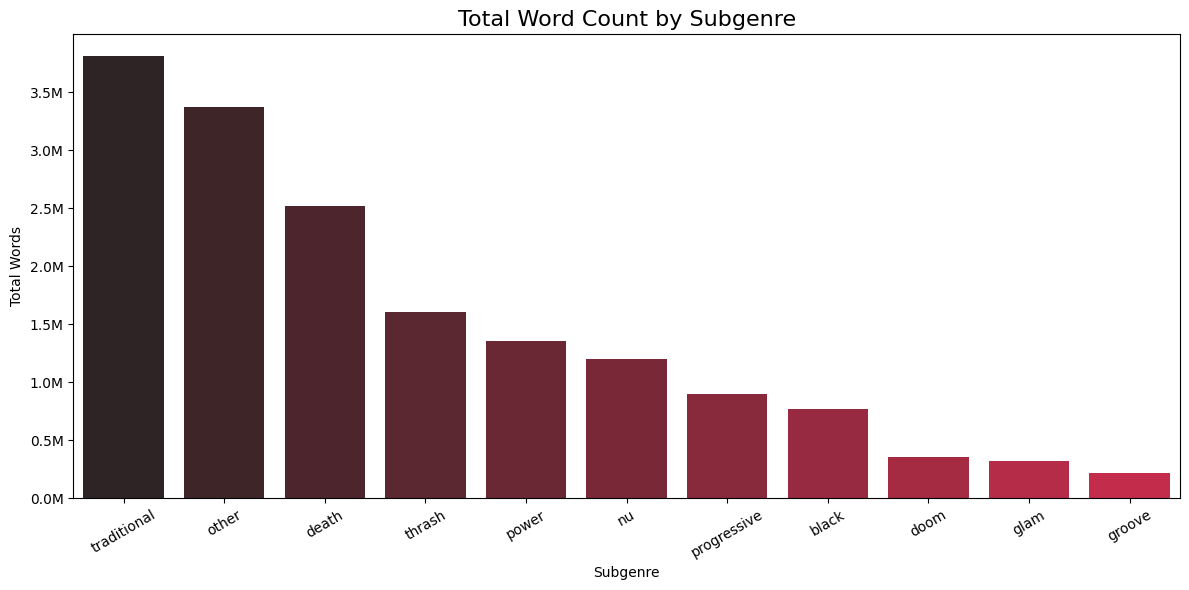

   subgenre  total_words
traditional      3809323
      other      3377473
      death      2520073
     thrash      1608823
      power      1358275
         nu      1198139
progressive       900678
      black       768146
       doom       354000
       glam       318786
     groove       219309


In [219]:
# Word count by subgenre

df_words = pd.read_sql("SELECT * FROM words", conn)

totals = {s: df_words[s].sum() for s in subgenres}
totals_df = pd.DataFrame(list(totals.items()), columns=['subgenre', 'total_words'])
totals_df = totals_df.sort_values('total_words', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=totals_df, x='subgenre', y='total_words', hue='subgenre', palette='dark:crimson', legend=False)
plt.title('Total Word Count by Subgenre', fontsize=16)
plt.xlabel('Subgenre')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))
plt.ylabel('Total Words')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(totals_df.to_string(index=False))

---

###  Country Representation

This dataset includes lyrics of bands from 45 countries. The United States leads by a significant margin, showing both the country's outsized influence on metal's development and the sheer size of its music scene. The next highest-represented countries are the UK, Sweden, and Germany, three countries whose influence on heavy metal is disproportionate to their size. This sets up an interesting per-capita question explored later in the findings.

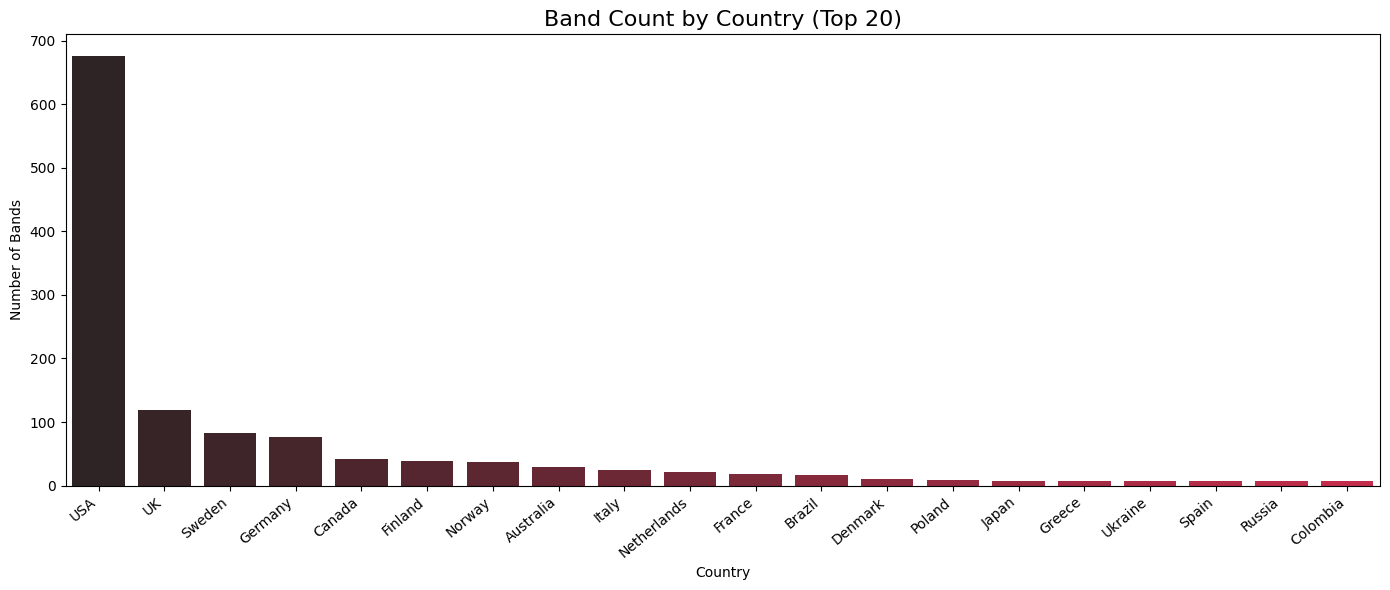

    country  band_count
        USA         676
         UK         119
     Sweden          82
    Germany          77
     Canada          42
    Finland          39
     Norway          37
  Australia          29
      Italy          24
Netherlands          22
     France          19
     Brazil          16
    Denmark          11
     Poland           9
      Japan           8
     Greece           8
    Ukraine           7
      Spain           7
     Russia           7
   Colombia           7


In [220]:
df_artists = pd.read_sql("SELECT country, COUNT(*) as band_count FROM artists GROUP BY country ORDER BY band_count DESC LIMIT 20", conn)

plt.figure(figsize=(14, 6))
sns.barplot(data=df_artists, x='country', y='band_count', hue='country', palette='dark:crimson', legend=False)
plt.title('Band Count by Country (Top 20)', fontsize=16)
plt.xlabel('Country')
plt.ylabel('Number of Bands')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

print(df_artists.to_string(index=False))

---

### Release Year Distribution

The corpus spans from 1968 to 2026. The earliest release included is the song *Helter Skelter* by The Beatles, and the first true "metal" album is Black Sabbath's self-titled album from 1970. Release count grows steadily through the 70s, 80s, and 90s before peaking in 2004, with 265. The decline starting in the mid-2010's is somewhat misleading; it likely reflects a selection bias towards the releases catalogued online and used in this project, not a decline in metal output. The album *Painkiller* (1990) by Judas Priest has had 36 years to earn its reputation; a 2022 release hasn't had that time yet.

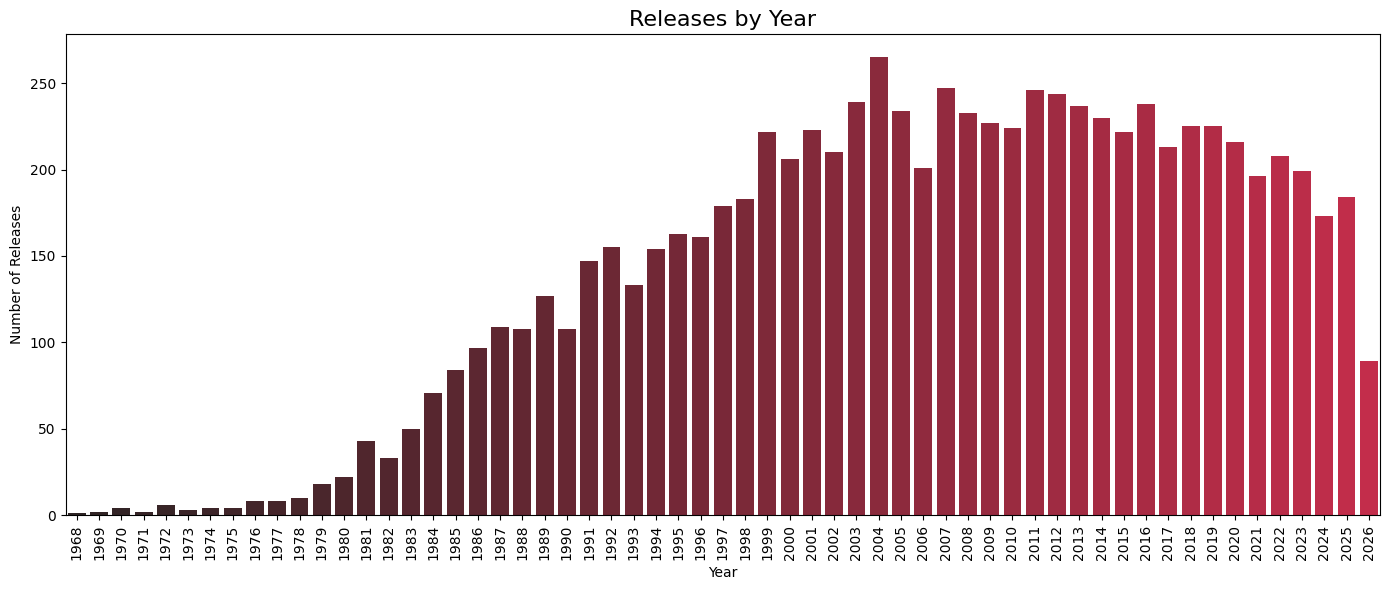

Earliest release: 1968
Most recent release: 2026
Most active year: 2004 (265 releases)


In [221]:
df_years = pd.read_sql("""
    SELECT year, COUNT(*) as release_count
    FROM releases
    WHERE year != 'Unknown'
    GROUP BY year
    ORDER BY year
""", conn)

df_years['year'] = pd.to_numeric(df_years['year'], errors='coerce')
df_years = df_years.dropna()

plt.figure(figsize=(14, 6))
sns.barplot(data=df_years, x='year', y='release_count', hue='year', palette='dark:crimson', legend=False)
plt.title('Releases by Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Number of Releases')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print(f"Earliest release: {int(df_years['year'].min())}")
print(f"Most recent release: {int(df_years['year'].max())}")
print(f"Most active year: {int(df_years.loc[df_years['release_count'].idxmax(), 'year'])} ({df_years['release_count'].max()} releases)")

---

### Vocalist Gender Breakdown

95% of the releases in this dataset feature male vocalists; releases with female vocalists make up almost 5%, and bands with both male and female vocalists make up a fraction of a percent. Metal has always been a male-dominated music genre, and I made a deliberate effort to seek out bands with female vocalists to improve representation in this dataset. 

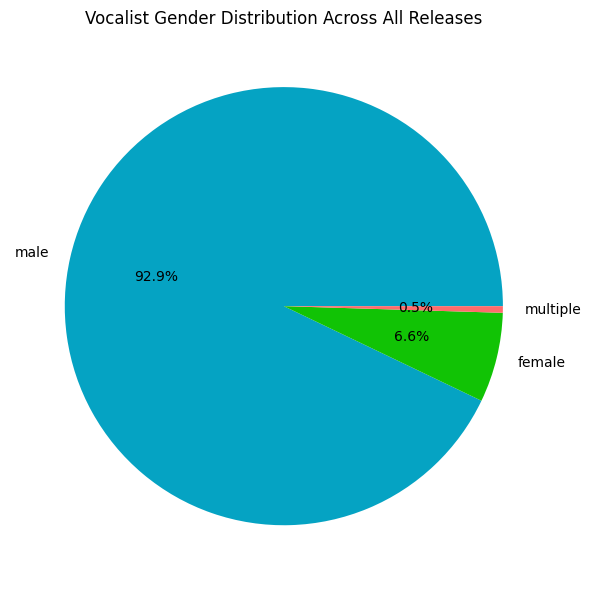

vocalist_gender  count
           male   7687
         female    548
       multiple     40


In [222]:
df_gender = pd.read_sql("""
    SELECT vocalist_gender, COUNT(*) as count
    FROM releases
    GROUP BY vocalist_gender
    ORDER BY count DESC
""", conn)

plt.figure(figsize=(8, 6))
plt.pie(df_gender['count'], labels=df_gender['vocalist_gender'], autopct='%1.1f%%', 
        colors=['#05a3c3', '#11c305', '#FF6B6B', '#FFB3B3'])
plt.title('Vocalist Gender Distribution Across All Releases', fontsize=12)
plt.tight_layout()
plt.show()

print(df_gender.to_string(index=False))

---

### Vocalist Gender by Subgenre

Which subgenres have the most female representation? For this question, I used Discogs' more specific subgenre classification system. 

Of the eight subgenres with the highest female vocalist representation, only one maps directly to one of the ten named subgenres in this analysis: Nu Metal. Symphonic Metal (44.7%) and Gothic Metal (39.3%) both significantly exceed Nu Metal's representation, but were collapsed into the broader categories of Power Metal and Other. 

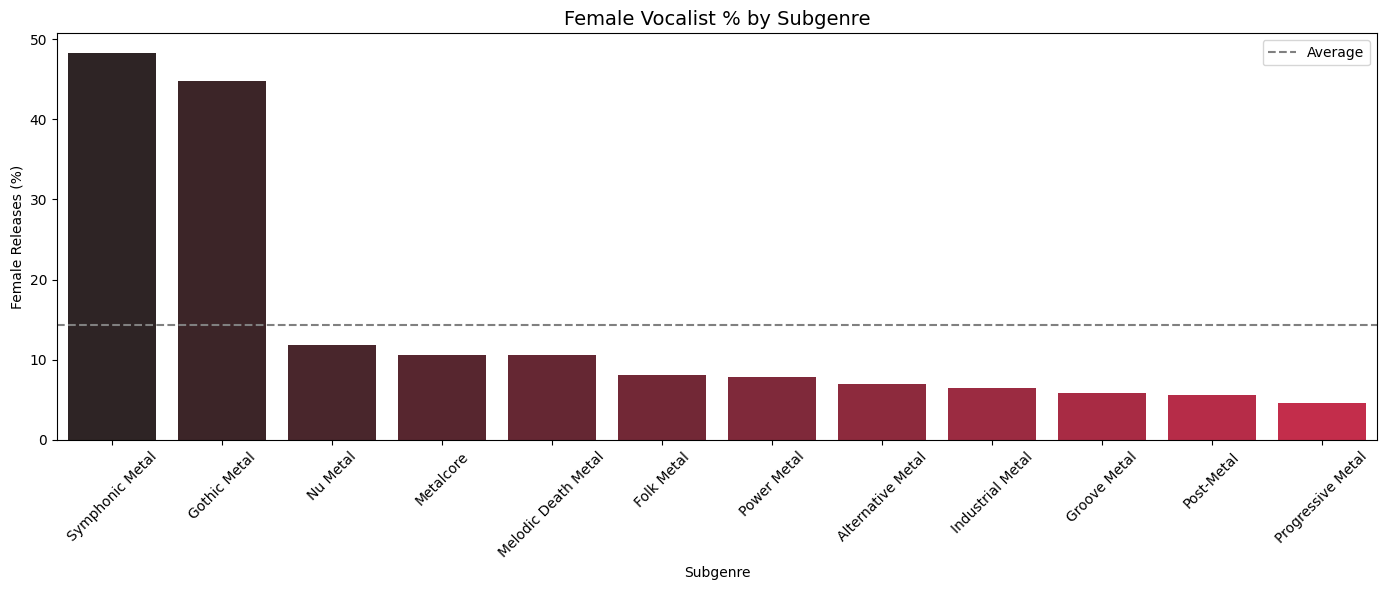

      subgenre_name  female_releases  male_releases  total_releases  female_pct
    Symphonic Metal              128            134             265        48.3
       Gothic Metal               69             85             154        44.8
           Nu Metal               55            413             468        11.8
          Metalcore               72            605             681        10.6
Melodic Death Metal               20            168             189        10.6
         Folk Metal               10            112             123         8.1
        Power Metal               38            442             482         7.9
  Alternative Metal               19            250             270         7.0
   Industrial Metal                5             72              77         6.5
       Groove Metal                6             97             103         5.8
         Post-Metal                4             67              71         5.6
  Progressive Metal               24    

In [223]:
df_gender_subgenre = pd.read_sql("""
    SELECT 
        subgenre_name,
        SUM(CASE WHEN vocalist_gender = 'female' THEN 1 ELSE 0 END) as female_releases,
        SUM(CASE WHEN vocalist_gender = 'male' THEN 1 ELSE 0 END) as male_releases,
        COUNT(*) as total_releases,
        ROUND(100.0 * SUM(CASE WHEN vocalist_gender = 'female' THEN 1 ELSE 0 END) / COUNT(*), 1) as female_pct
    FROM release_subgenres
    GROUP BY subgenre_name
    HAVING total_releases > 10
    AND subgenre_name LIKE '%Metal%' --This analysis uses Discogs' more granular subgenre list, so filtering for having "Metal" in the name prevents other genres like J-Pop or Ambient from appearing
    AND female_releases > 0
    ORDER BY female_pct DESC
    LIMIT 12
""", conn)

plt.figure(figsize=(14, 6))
sns.barplot(data=df_gender_subgenre, x='subgenre_name', y='female_pct',
            hue='subgenre_name', palette='dark:crimson', legend=False)
plt.title('Female Vocalist % by Subgenre', fontsize=14)
plt.xlabel('Subgenre')
plt.ylabel('Female Releases (%)')
plt.tick_params(axis='x', rotation=45)
plt.axhline(y=df_gender_subgenre['female_pct'].mean(), color='gray', linestyle='--', label='Average')
plt.legend()
plt.tight_layout()
plt.show()

print(df_gender_subgenre[['subgenre_name', 'female_releases', 'male_releases', 'total_releases', 'female_pct']].to_string(index=False))


---

The dataset is large, geographically and gender-diverse, and deliberately curated. With that context established, the real questions begin.

---

## Universal Metal Vocabulary

### The 10 Most Common Words in Heavy Metal Music

"What are the most common words used in heavy metal?" was the question that started this whole project, and that is the first thing I want to answer.

,Word,Total
1,life,56306
2,world,38344
3,feel,34917
4,eyes,31181
5,love,30436
6,death,30226
7,die,29058
8,night,27506
9,blood,26670
10,end,26076


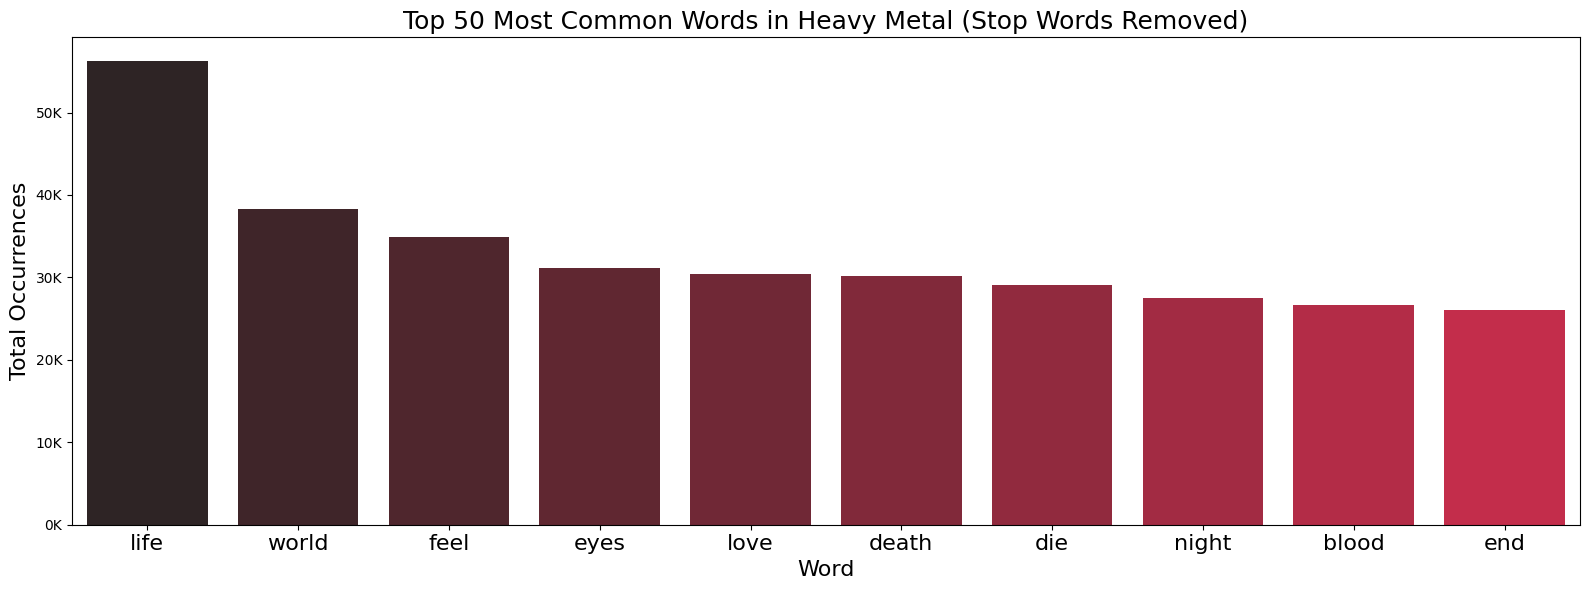

In [236]:
stop_words = {
    'the', 'and', 'to', 'of', 'a', 'in', 'i', 'you', 'my', 'is', 'it', 
    'me', 'for', 'on', 'we', 'no', 'that', 'will', 'your', 'all', 'this', 
    'are', 'be', 'with', 'not', 'but', 'so', 'as', 'have', 'from', 'or', 
    'an', 'at', 'by', 'they', 'do', 'if', 'was', 'their', 'our', 'its', 
    'been', 'has', 'her', 'him', 'his', 'she', 'he', 'can', 'what', 'when', 
    'there', 'than', 'more', 'up', 'out', 'am', 'into', 'us', 'would', 
    'who', 'which', 'had', 'were', 'one', 'about', 'just', 'now', 'like', 
    'how', 'know', 'get', 'go', 'come', 'see', 'time', 'way', 'could', 
    'make', 'take', 'through', 'over', 'back', 'down', 'then', 'only', 
    'some', 'other', 'new', 'also', 'two', 'may', 'after', 'where', 'much', 
    'before', 'here', 'away', 'still', 'even', 'never', 'those', 'them', 
    'these', 'such', 'own', 'too', 'very', 'well', 'did', 'should', 'while', 
    'off', 'again', 'same', 'upon', 'every', 'between', 'under', 'let',
    'don', 'got', 'say', 'said', 'til', 'cause', 'ain', 'gonna', 'wanna',
    'gotta', 'yeah', 'oh', 'ah', 'ha', 'na', 'la', 'da', 'wo', 'hey',
    'ooh', 'uh', 'whoa', 'mmm', 'huh', 'em', 'im', 've', 're', 'll',
    'i\'m', 'it\'s', 'you\'re', 'he\'s', 'she\'s', 'they\'re', 'we\'re', 
    'we\'ve', 'you\'ve', 'they\'ve', 'don\'t', 'i\'ll', 'he\'ll', 'she\'ll',
    'we\'ll', 'can\'t', 'i\'ve', 'there\'s', 'won\'t'
}

df_meaningful10 = df_words[~df_words['word'].isin(stop_words)].copy()
df_meaningful10['total'] = df_meaningful10[subgenres].sum(axis=1)
df_meaningful10 = df_meaningful10.sort_values('total', ascending=False).head(10)

df_display = df_meaningful10[['word', 'total']].head(10).copy()
df_display.columns = ['Word', 'Total']
df_display = df_display.reset_index(drop=True)
df_display.index += 1
display(df_display)

plt.figure(figsize=(16, 6))
sns.barplot(data=df_meaningful10, x='word', y='total',
            hue='word', palette='dark:crimson', legend=False)
plt.title('Top 50 Most Common Words in Heavy Metal (Stop Words Removed)', fontsize=18)
plt.xlabel('Word', fontsize=16)
plt.ylabel('Total Occurrences', fontsize=16)
plt.xticks(rotation=0, ha='center', fontsize=16)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1_000:.0f}K'))
plt.tight_layout()
plt.show()


#print("Top 10 most common meaningful words:")
#print()
#print(f"{'word':>5} {'total':>5}")
#print()
#print(df_meaningful[['word', 'total']].head(10).to_string(index=False, header=False))

These 10 words are so far above and beyond what I was hoping to find. Almost a decade ago, I made a silly little program to disprove someone else's claim (See README.md if you need context), and now the same question has led me to make this project and find this beautiful list. So much can be inferred from just these 10 words. 

First, and most obvious, the clear distinction between 5 positive-leaning words on top and 5 negative-leaning words on the bottom. Second, "life" and "love" appear more commonly than "death" and "die". And those are just surface-level findings. For example, you can use "life" in a positive or a negative context (i.e., "this life is beautiful" or "this life sucks"), but you can't really use "death" or "die" in a positive one. A sentiment analysis could reveal *how* "life" is really used and what metal music thinks about being alive.

This simple query answered my decade-old question and made me so excited to keep exploring. 

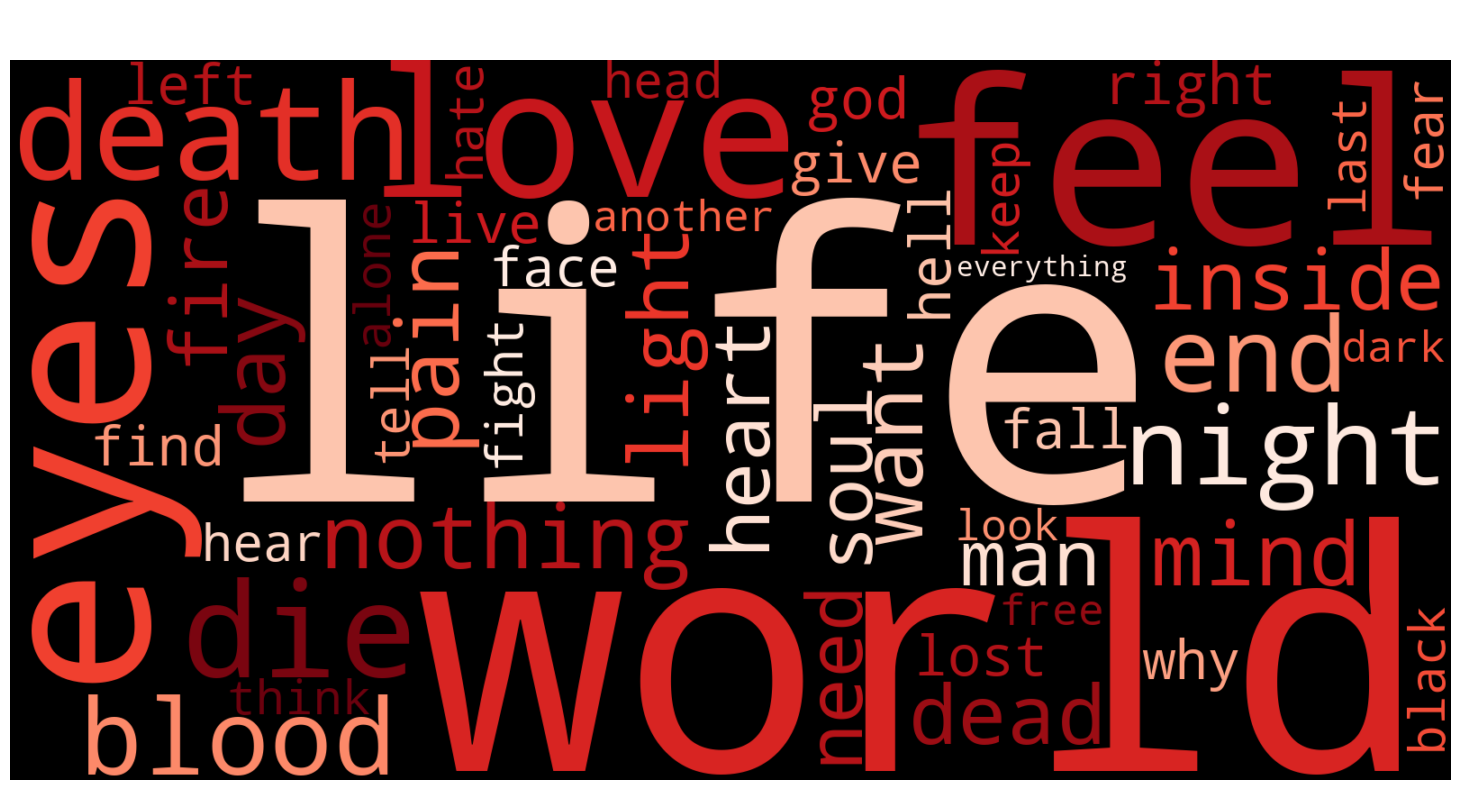

In [237]:
from wordcloud import WordCloud

df_meaningful50 = df_words[~df_words['word'].isin(stop_words)].copy()
df_meaningful50['total'] = df_meaningful50[subgenres].sum(axis=1)
df_meaningful50 = df_meaningful50.sort_values('total', ascending=False).head(50)

# Build a frequency dictionary from the top meaningful words
word_freq = dict(zip(df_meaningful50['word'], df_meaningful50['total']))

wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='black',
    colormap='Reds',
    max_words=100,
    prefer_horizontal=0.7
).generate_from_frequencies(word_freq)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Heavy Metal', fontsize=20, color='white', pad=20)
plt.tight_layout()
plt.show()

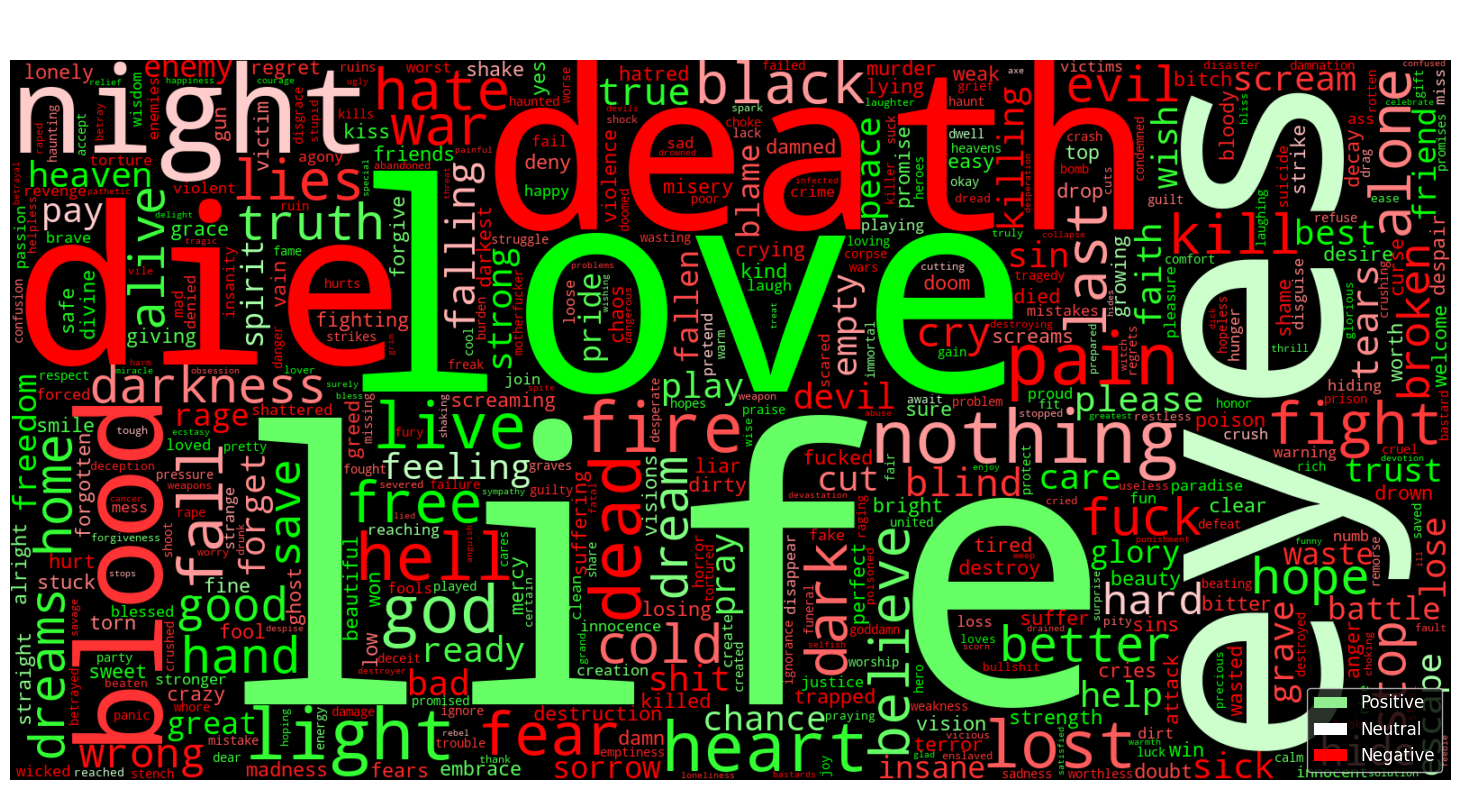

In [294]:
from wordcloud import WordCloud
import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.colors as mcolors

sia = SentimentIntensityAnalyzer()

df_meaningful100 = df_words[~df_words['word'].isin(stop_words)].copy()
df_meaningful100['total'] = df_meaningful100[subgenres].sum(axis=1)
df_meaningful100 = df_meaningful100.sort_values('total', ascending=False).head(2000)

# Scores from -1.0 to 1.0, overriding VADER where it falls short
metal_overrides = {
    'life':     0.3, #mostly positive, but can be used in a negative context
    'night':   -0.1, #dark, a little atmospheric
    'nothing': -0.2, #pessimistic, but can be used in a positive context
    'eyes':     0.1, 
    'light':    0.4,
    'black':   -0.2,
    'blood':   -0.4,
    'live':     0.6,
    'dark':    -0.3,
    'fall':    -0.2,
    'heart':    0.4,
    'believe':  0.3,
    'cold':    -0.3,
    'last':    -0.2,
    'home':     0.4
}

def get_final_score(word):
    if word.lower() in metal_overrides:
        return metal_overrides[word.lower()]
    return sia.polarity_scores(word)['compound']

df_meaningful100['vader_score'] = df_meaningful100['word'].apply(get_final_score)
df_sentiment_filtered = df_meaningful100[df_meaningful100['vader_score'].abs() >= 0.1]

word_freq = dict(zip(df_sentiment_filtered['word'], df_sentiment_filtered['total']))

wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='black',
    max_words=1000,
    prefer_horizontal=0.7,
    color_func=get_sentiment_color
).generate_from_frequencies(word_freq)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Heavy Metal — Colored by Sentiment', fontsize=20, color='white', pad=20)

# Add a legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='lightgreen', label='Positive'),
    Patch(facecolor='white', label='Neutral'),
    Patch(facecolor='red', label='Negative')
]
plt.legend(handles=legend_elements, loc='lower right', 
           facecolor='black', labelcolor='white', fontsize=12)

plt.tight_layout()
plt.show()